In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.patches as patches
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
plt.rcParams.update(config)
from matplotlib.ticker import AutoMinorLocator

import astropy
import astropy.units as u
import seaborn as sns

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()

1102


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_within_coverage,grating_slitloss_correction,lines_fit,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}


In [ ]:
count=0
redshifts=[]
for surveyid_subid, catalog in tqdm(DJAv4Catalog.catalog_iterator()):

    if catalog['prism_filepath'] is None:
        continue
    if catalog['determined_redshift'] is not None:

        if catalog['determined_redshift']>9.6 or catalog['determined_redshift']<2.0:
            continue

        redshifts.append(catalog['determined_redshift'])

    count+=1
print(count)

43042it [00:00, 101100.68it/s]

20912


(array([1740., 1267., 1246., 1205., 1030.,  961.,  670.,  720.,  562.,
         337.]),
 array([3.6001 , 4.02002, 4.43994, 4.85986, 5.27978, 5.6997 , 6.11962,
        6.53954, 6.95946, 7.37938, 7.7993 ]),
 <BarContainer object of 10 artists>)

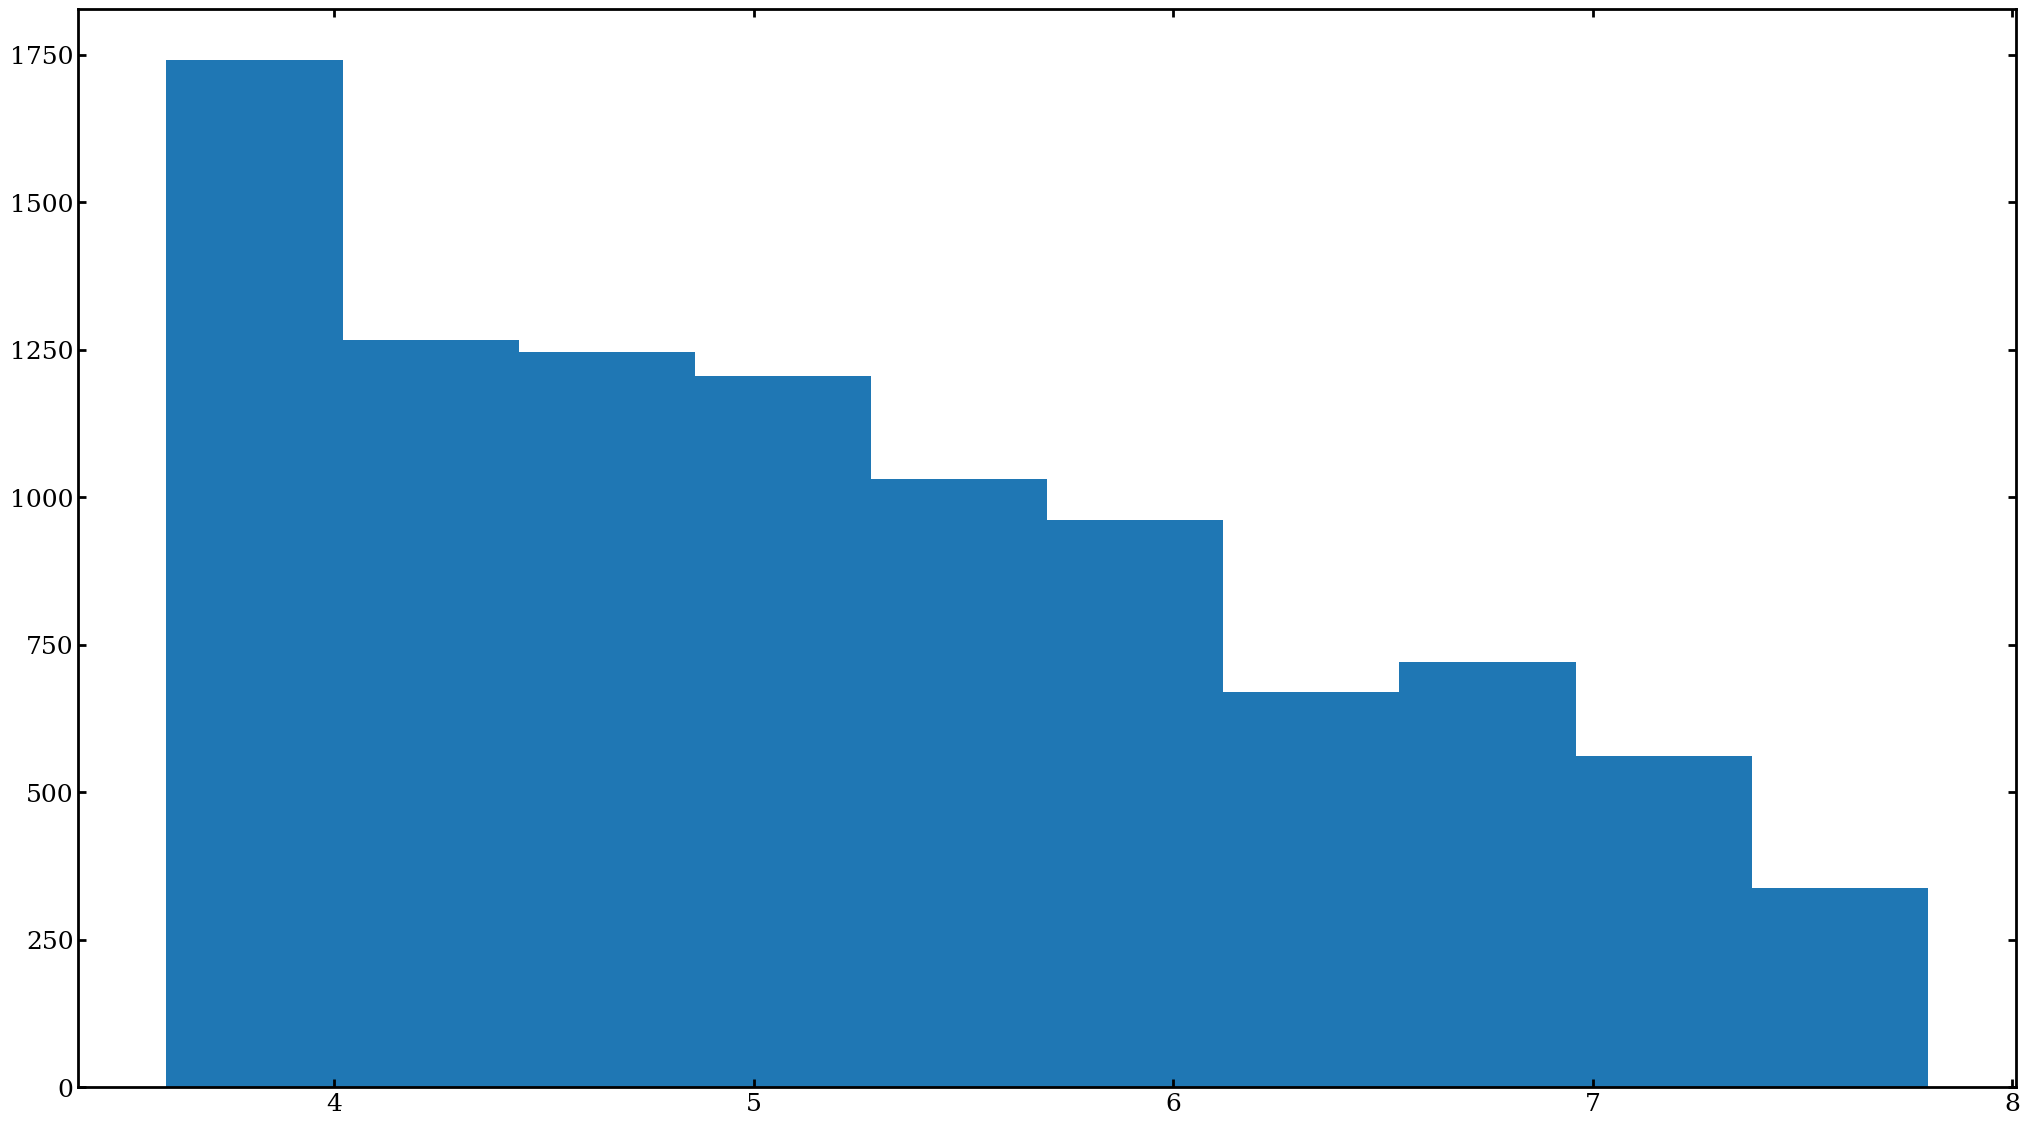

In [3]:
plt.hist(redshifts)

In [4]:
def power_law(x, a, b):
    return a * x ** b
from scipy.optimize import curve_fit
count=0
UV_slopes=[]
opt_slopes=[]
from tqdm import tqdm
for surveyid_subid, catalog in tqdm(DJAv4Catalog.catalog_iterator()):
    if catalog['prism_filepath'] is None:
        continue
    if catalog['determined_redshift'] is not None:
        if catalog['determined_redshift']>7.8 or catalog['determined_redshift']<3.6:
            continue

    prism_spectrum=FL.Load_Spectrum_From_Fits(catalog['prism_filepath'],catalog['determined_redshift'])
    prism_spectrum.set_boundarys(1300*u.AA,3600*u.AA)

    UV_wavelengths=prism_spectrum.processing_wavelengths.data
    UV_fluxlambda=prism_spectrum.processing_flux_lambda.data
    if len(UV_wavelengths)<10:
        continue
    valid_uv = (UV_fluxlambda > 0) & (UV_wavelengths > 0)
    x_uv = UV_wavelengths[valid_uv]
    y_uv = UV_fluxlambda[valid_uv]

    if len(x_uv) > 10:
        # 2. 在对数空间进行线性拟合 (degree=1)
        # 结果 coeffs[0] 是斜率(beta), coeffs[1] 是截距
        coeffs = np.polyfit(np.log10(x_uv), np.log10(y_uv), 1)
        UV_slopes.append(coeffs[0])
    else:
        UV_slopes.append(np.nan) #

    opt_lines = [
(r'[O II]',   3727.0),
(r'[Ne III]', 3869.0),
(r'H$\gamma$',  4340.0),
(r'[O III]',  4363.0),
(r'H$\beta$',  4861.0),
(r'[O III]',  4959.0),
(r'[O III]',  5007.0),
(r'H$\alpha$', 6563.0),
]
    prism_spectrum.set_boundarys(4000*u.AA,7000*u.AA)

    opt_lines_wavelengths=prism_spectrum.processing_wavelengths.data
    opt_lines_fluxlambda=prism_spectrum.processing_flux_lambda.data

    for line_name,line_wavelength in opt_lines:
        if line_wavelength>=opt_lines_wavelengths.min() and line_wavelength<=opt_lines_wavelengths.max():
            width=200*u.AA
            index_region= (opt_lines_wavelengths>=line_wavelength - width.to(u.AA).value/2) & (opt_lines_wavelengths<=line_wavelength + width.to(u.AA).value/2)
            opt_lines_fluxlambda[index_region]=np.nan

    mask_opt = (~np.isnan(opt_lines_fluxlambda)) & (opt_lines_fluxlambda > 0)
    x_opt = opt_lines_wavelengths[mask_opt]
    y_opt = opt_lines_fluxlambda[mask_opt]

    if len(x_opt) > 10:
        coeffs_opt = np.polyfit(np.log10(x_opt), np.log10(y_opt), 1)
        opt_slopes.append(coeffs_opt[0])
    else:
        opt_slopes.append(np.nan)


    count+=1

43042it [01:38, 435.61it/s] 


In [6]:
count

9738

In [7]:
UV_slopes=np.array(UV_slopes)
opt_slopes=np.array(opt_slopes)



In [8]:
UV_slopes

array([-0.23902127, -2.31963333, -1.71932443, ..., -2.05389893,
       -1.57413073, -1.14422078], shape=(9738,))

In [9]:
UV_slopes.shape

(9738,)

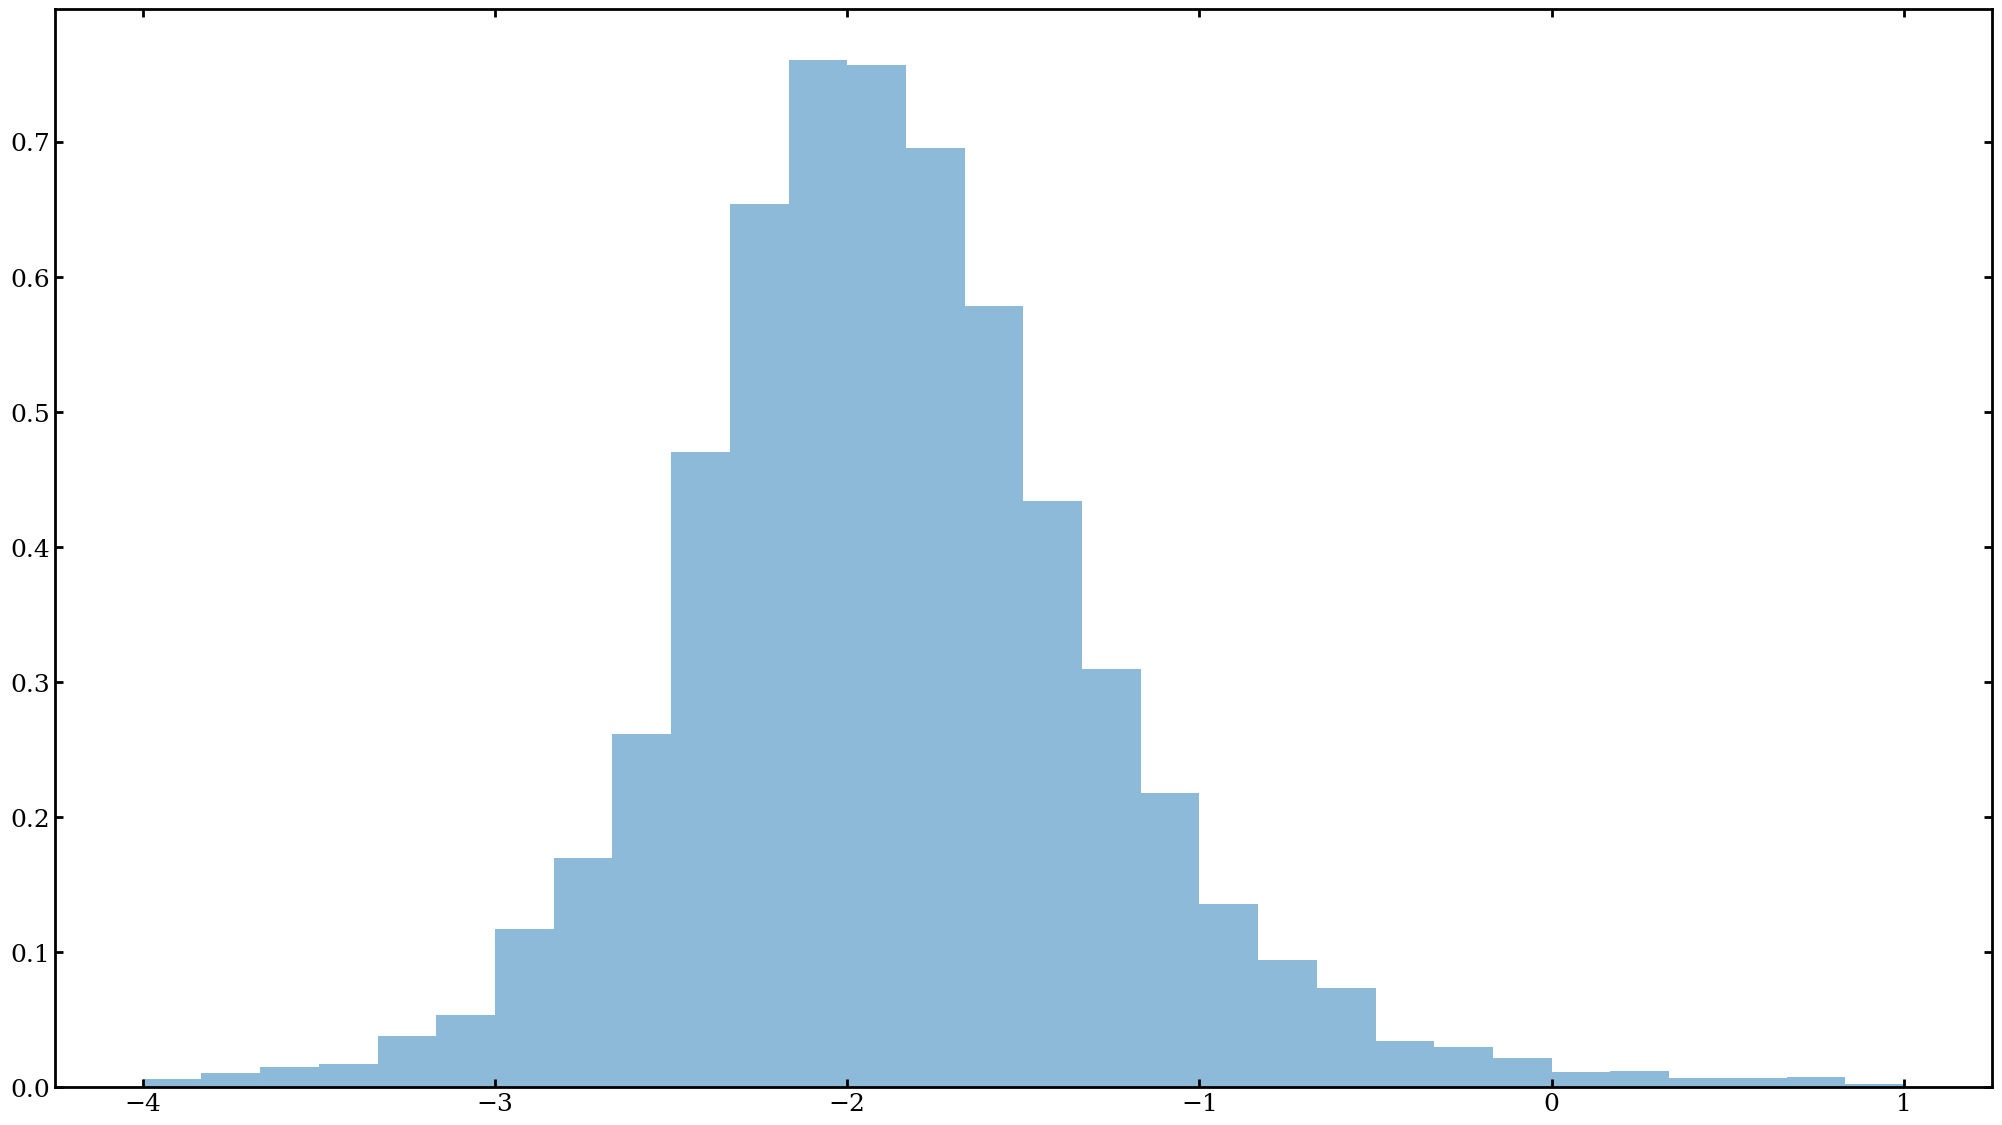

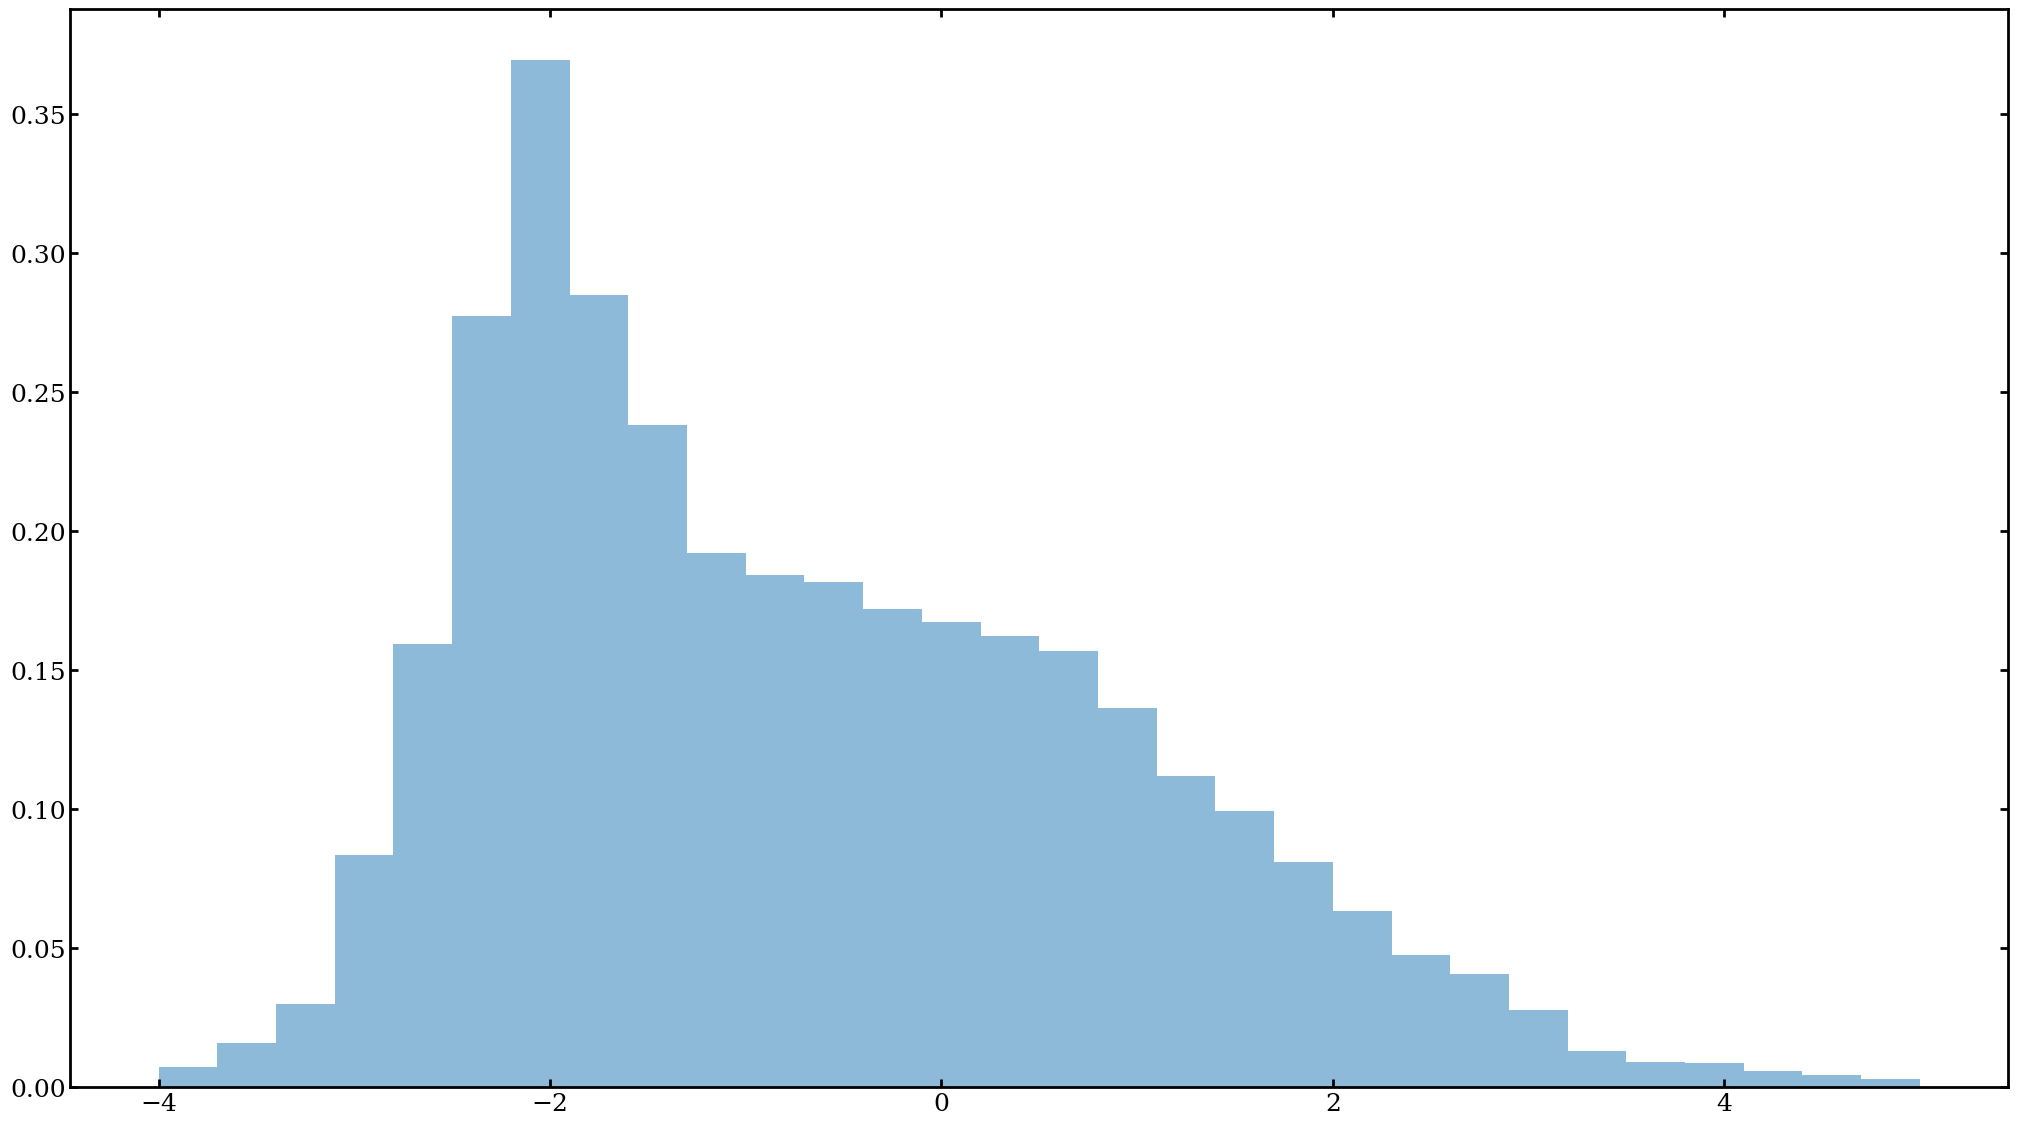

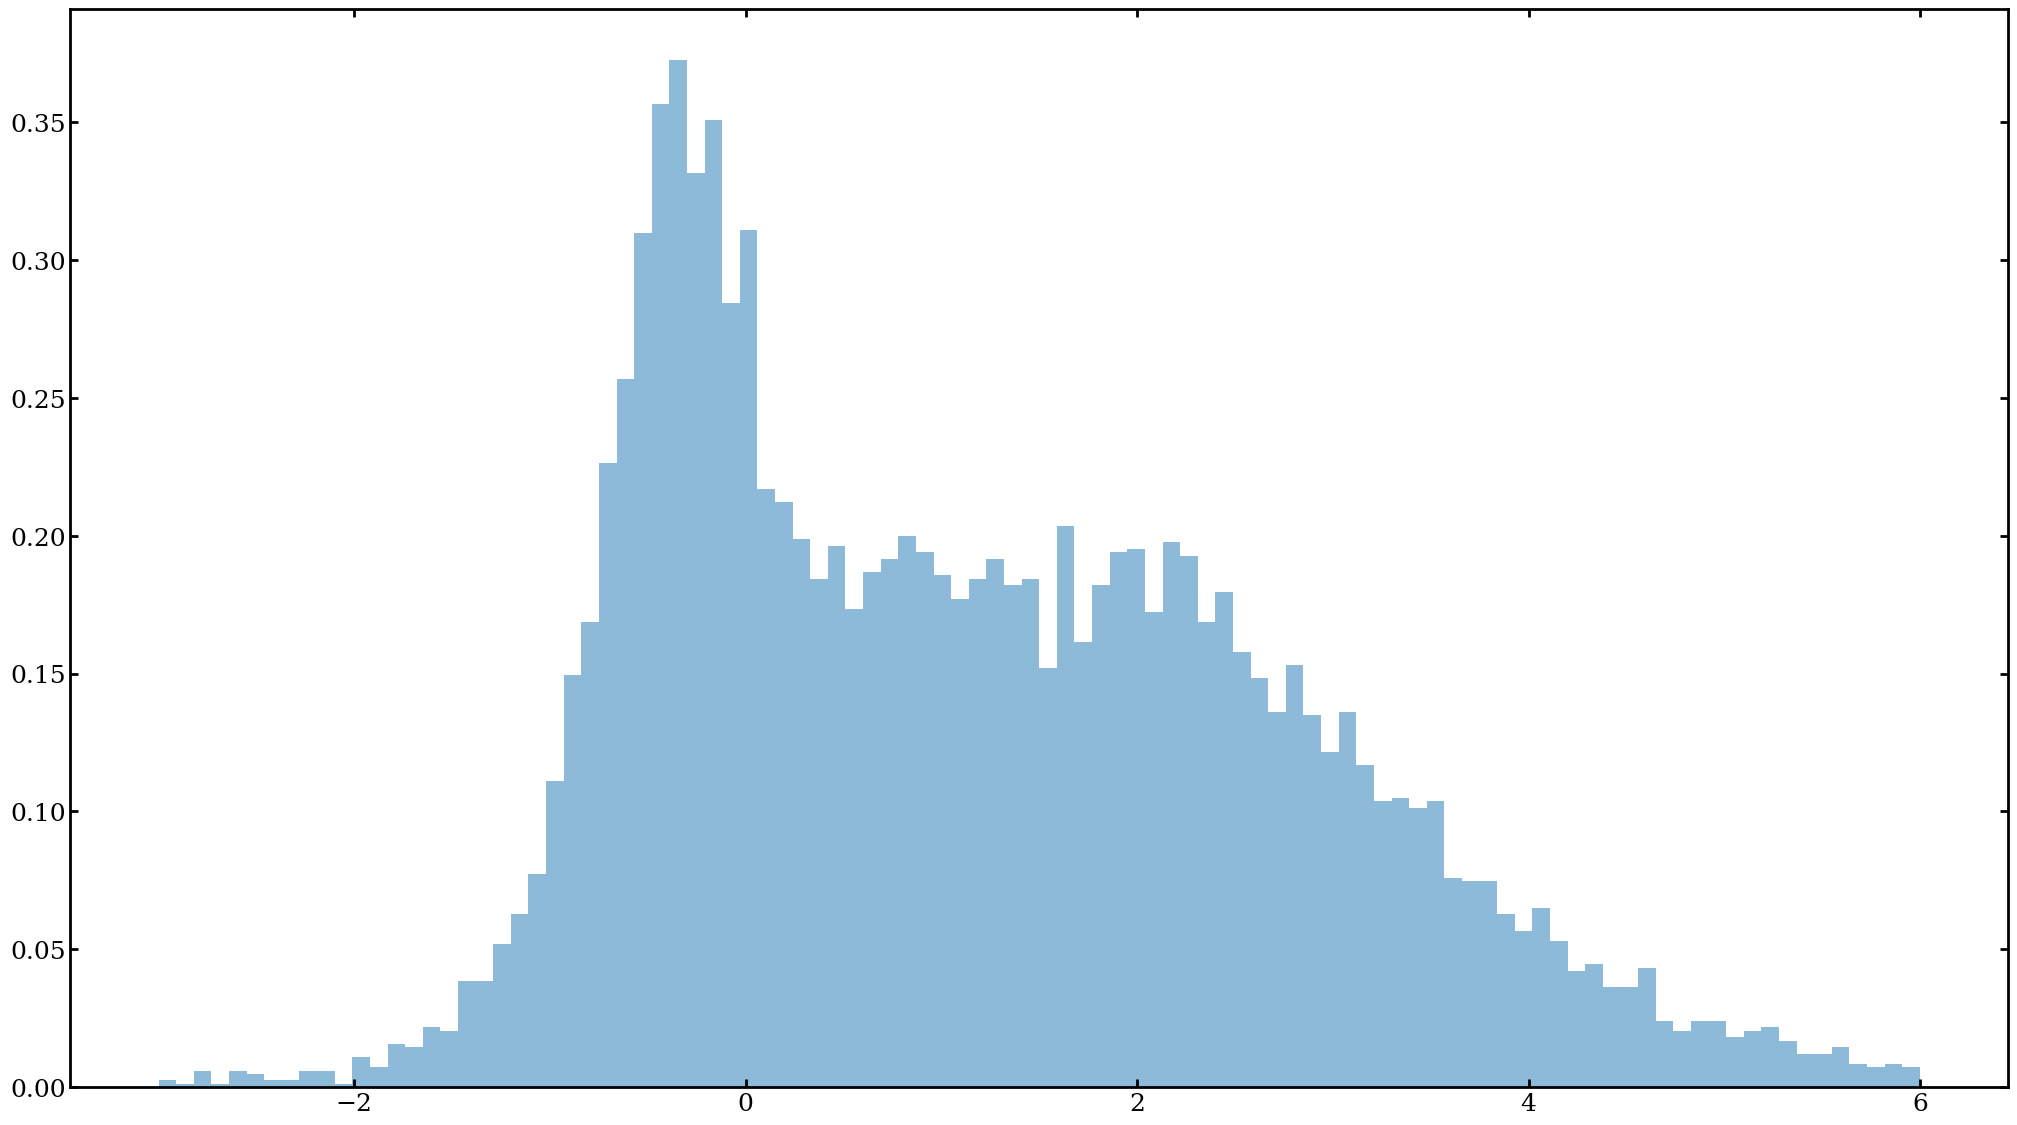

In [10]:
plt.hist(UV_slopes,bins=30,alpha=0.5,label='UV slopes',density=True,range=(-4,1))

plt.show()
plt.hist(opt_slopes,bins=30,alpha=0.5,label='optical slopes',density=True,range=(-4,5))
plt.show()
plt.hist(opt_slopes-UV_slopes,bins=100,alpha=0.5,label='optical slopes minus UV slopes',density=True,range=(-3,6))
plt.show()